In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import ThomasFermi

From notes Chris made in paper: 

The single-electron states are of the form
$\begin{equation}
\psi_{nkm}(r,\theta,\phi) = \frac1{r\sqrt{\sin\theta}}[F_{nk}(r)\Theta^{(F)}_{km}(\theta,\phi) + G_{nk}(r) \Theta^{(G)}_{km}(\theta,\phi)]
\end{equation}$

where the radial functions satisfy (with units put back in)

$\begin{equation}
\left( \begin{array}{cc}
m_ec^2+q_eV & \hbar c(\frac kr + \partial_r) \\
\hbar c(\frac kr - \partial_r) & -m_ec^2+q_eV
\end{array} \right)
\left(\begin{array}{c} F_{nk}(r) \\ G_{nk}(r) \end{array}\right)
=
h_{nk}\left(\begin{array}{c} F_{nk}(r) \\ G_{nk}(r) \end{array}\right).
\end{equation}$

reordered to be a bit clearer 
$\begin{eqnarray}
-\frac{m_e c^2 + q_e V -h_{nk}}{\hbar c}F_{nk}(r) -  (\frac{k}{r})G_{nk}(r) &=& \partial_r G_{nk}(r) \\
\frac{k}{r} F_{nk}(r) + \frac{-m_e c^2 +q_e V - h_{nk}}{\hbar c }G_{nk}(r) & =& \partial_r F_{nk}(r)
\end{eqnarray}$

In [2]:
r_bohr_H = 5.2946541e-11 # bohr radius in meters
r_bohr_Mg = r_bohr_H/80 
r_min = r_bohr_Mg/3
print(r_min)

2.2061058750000002e-13


In [3]:
a_from_paper = 6.468e-10 

#r_max = (3*vol_per_atom/(4*np.pi))**(1/3) 
r_max = a_from_paper 

In [4]:
r_array = np.logspace(-13,-9.2,100)
pot_Hg = np.zeros(len(r_array))
pot_Cd = np.zeros(len(r_array))
pot_Te = np.zeros(len(r_array))
for i in range(len(r_array)):
    pot_Hg[i] = ThomasFermi.Potential(80,r_array[i])
    pot_Cd[i] = ThomasFermi.Potential(52,r_array[i])
    pot_Te[i] = ThomasFermi.Potential(48,r_array[i])

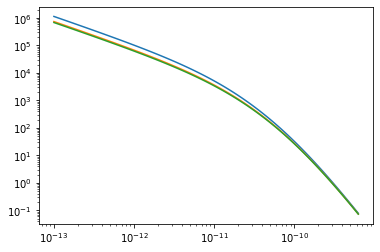

In [5]:
plt.loglog(r_array, pot_Hg)
plt.loglog(r_array, pot_Cd)
plt.loglog(r_array, pot_Te)
plt.show()

In [223]:
class ElectronWaveFunctionGRC:
    
    """
    
    Electron Wave Function class implements the parameters and RK-4 method for the electron's radial part of the 
    wave function.
    
    
    Parameters
    ----------
    
    nu: float
    
    k: float
       quantum number 
    
    h: float
       Energy eigenvalue 
    
    
    mu: float
        mass of the electron
    
    """

    def __init__(self, n, k, h, tol,Z):
        
        self.n = n
        self.k = k
        self.h = h
        self.mu = 9.1093837e-31 #kilograms #define in right units here
        self.c = 299792458. #m/s  #define in right units here
        self.hbar = 1.054571817e-34 #Js #define in right units here 
        self.charge = -1.60217663e-19 #V
        self.alpha = 0.0072973525643 #alpha 
        self.Z =  Z #define this 
        self.tol = tol

        
        self.nu = np.sqrt(self.k**2 - (self.alpha*self.Z)**2) 
        #print(self.nu,(self.alpha*self.Z)**2)
        self.coeff = None

    def potential(self, r):
        return ThomasFermi.Potential(self.Z,r)
    
    def diff_eq(self, r, F, G):
        
        dG = (self.h -self.mu*self.c**2 - self.charge*self.potential(r))* F/self.hbar/self.c  - (self.k/r)*G
            
        dF = (self.k/r) * F + (-self.h -self.mu*self.c**2 + self.charge*self.potential(r)) * G /self.hbar/self.c

        return np.asarray([dF, dG])
    
    
    def RK_4(self, r_min, r_inf, N):
        
        #this is in terms of r_star
        
        step_size = (r_inf - r_min) / (N-1)
        #print(step_size)
        
        r_points = np.linspace(r_min, r_inf, N)        
        
        #print(r_points[0])
        
        
        #Define initial values for F and G
        #inner boundary condition
        F = np.sqrt(self.k**2 - self.nu**2)
        G = self.k - self.nu

        #print(F,G)
        #outer boundary condition is F = G
        
        #Arrays to keep track of r, F and G points:

        F_points = []
        G_points = []
        K_counts = []
        counter_K = 0
        K_check = 2.**60
        
        for r in r_points:  
            #Update F_points and G_points arrays:
            F_points.append(F)
            G_points.append(G)


            #Calculate all the slopes (each variable has a separate k-slope):
            (k1F, k1G) = tuple(step_size * self.diff_eq(r, F, G))

            (k2F, k2G) = tuple(step_size * self.diff_eq(r + 0.5*step_size, F + 0.5*k1F, G + 0.5*k1G))

            (k3F, k3G) = tuple(step_size * self.diff_eq(r + 0.5*step_size, F + 0.5*k2F, G + 0.5*k2G))

            (k4F, k4G) = tuple(step_size * self.diff_eq(r + step_size, F + k3F, G + k3G))


            #Calculate next F_point and G_point
            F = F + (k1F + 2*k2F + 2*k3F + k4F) / 6
            G = G + (k1G + 2*k2G + 2*k3G + k4G) / 6
            if F**2 + G**2 > K_check:
                #print('true') 
                F = F/np.sqrt(K_check)
                G = G/np.sqrt(K_check)
                counter_K += 1 
            K_counts.append(counter_K)
        #want to normalize the last points of things 
        
        

        coeff = (np.sum(np.abs(F_points[1:-1]))**2 + np.sum(np.abs(G_points[1:-1])**2) + .5*(np.abs(F_points[0])**2+np.abs(F_points[-1])**2+ np.abs(G_points[0])**2+np.abs(G_points[-1]**2 )))* step_size

        self.coeff = coeff
        #print('coeff is ' + str(coeff))
        #F_points= F_points/coeff
        #G_points= G_points/coeff                                                                                                            
        return np.array(r_points), np.array(F_points), np.array(G_points), coeff, K_counts

        
    
        

In [224]:
n=1
k = 1
#tol = 1e-10 
Nr = 500
hmin = .5 * 1.60218e-19 #band gap energy eV to J
hmax = 10e6* 1.60218e-19 #takes me up to a MeV for now to J 
h = np.sqrt(hmin*hmax)
s = (hmax/hmin)**.25
#print(h,s)
tested_hs = [h]
tested_s = [s]
n_zeros = [0]
Z=80



def iterate_for_zeros(h,s,n,k,z,hsarray,sarray,nzeros): 

    # number of iterations is limited by how big s can be
    # and the number of bits stored in float64
    for _ in range(53+max(int(np.ceil(np.log2(s))),0)):
        testing = ElectronWaveFunctionGRC(n, k, h, tol,Z)
        temp_data_rs, temp_data_Fs, temp_data_Gs,coeff,K_count = testing.RK_4(r_min,r_max, Nr)
        #print(temp_data_rs[0], temp_data_Fs[0], temp_data_Gs[0])
        check_array = (temp_data_Fs- temp_data_Gs)
        #print(check_array)
        crossing_finder = check_array[:-1]*check_array[1:]
        num_zeros = (crossing_finder<0).sum()
        nzeros.append(num_zeros)
        #print(h,s,num_zeros)
        if num_zeros >= n: 
            h = h/s
            hsarray.append(h)
        else: 
            h = h*s
            hsarray.append(h)
        s = np.sqrt(s)
        sarray.append(s)
    return temp_data_rs, temp_data_Fs, temp_data_Gs, coeff, K_count    

        

In [225]:
data = iterate_for_zeros(h,s,n,k,Z,tested_hs,tested_s,n_zeros)

In [226]:
n2=2
k2 = 1
#tol = 1e-10 
h2 = np.sqrt(hmin*hmax)
s2 = (hmax/hmin)**.25
print(h2,s2)
tested_hs2 = [h2]
tested_s2 = [s2]
n_zeros2 = [0]
data2 = iterate_for_zeros(h2,s2,n2,k2,Z,tested_hs2,tested_s2,n_zeros2)

3.582583392190613e-16 66.8740304976422


In [227]:
tested_hs, tested_s

([3.582583392190613e-16,
  2.395817910297015e-14,
  1.9592170730982492e-13,
  6.851224236505824e-14,
  1.1585782449099726e-13,
  8.90936549447579e-14,
  7.812813885383498e-14,
  7.316238093914701e-14,
  7.079914388541399e-14,
  6.964630718937014e-14,
  6.907694751499535e-14,
  6.879401550996835e-14,
  6.865298437711594e-14,
  6.858257726806073e-14,
  6.854740079543286e-14,
  6.856498677588658e-14,
  6.8556193221767e-14,
  6.856058985784457e-14,
  6.855839150456135e-14,
  6.85572923543532e-14,
  6.855674278585737e-14,
  6.855701756955461e-14,
  6.855688017756832e-14,
  6.855694887352706e-14,
  6.855698322153223e-14,
  6.855700039554127e-14,
  6.855700898254741e-14,
  6.855701327605088e-14,
  6.855701112929911e-14,
  6.855701220267498e-14,
  6.855701166598705e-14,
  6.855701139764309e-14,
  6.855701126347111e-14,
  6.855701119638513e-14,
  6.855701116284214e-14,
  6.855701114607065e-14,
  6.855701113768491e-14,
  6.855701113349204e-14,
  6.855701113139562e-14,
  6.855701113244382e-14,
  

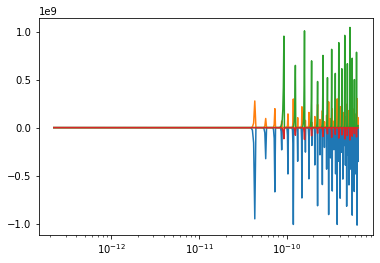

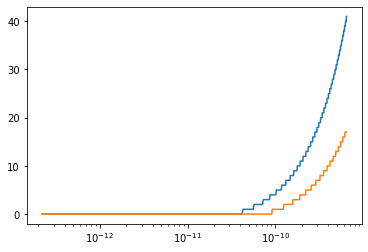

In [228]:
plt.plot(data[0],data[1])
plt.plot(data[0],data[2])
plt.plot(data2[0],data2[1])
plt.plot(data2[0],data2[2])

plt.xscale('log')
#plt.yscale('symlog')
plt.show()

plt.plot(data[0],data[4])
plt.plot(data2[0],data2[4])
plt.xscale('log')
#plt.yscale('symlog')
plt.show()


In [229]:
np.array(tested_hs)/1.60218e-19

array([   2236.0679775 ,  149534.87812212, 1222844.54499385,
        427618.88405209,  723126.14369794,  556077.68755544,
        487636.46315542,  456642.70518386,  441892.57065632,
        434697.1450734 ,  431143.48896501,  429377.56999818,
        428497.324752  ,  428057.87906515,  427838.3252533 ,
        427948.08807928,  427893.20314676,  427920.64473308,
        427906.92371994,  427900.06337835,  427896.63324881,
        427898.34831014,  427897.49077862,  427897.91954417,
        427898.1339271 ,  427898.24111861,  427898.29471437,
        427898.32151226,  427898.30811332,  427898.31481279,
        427898.31146305,  427898.30978818,  427898.30895075,
        427898.30853203,  427898.30832267,  427898.30821799,
        427898.30816565,  427898.30813949,  427898.3081264 ,
        427898.30813294,  427898.30812967,  427898.30812804,
        427898.30812722,  427898.30812763,  427898.30812742,
        427898.30812732,  427898.30812737,  427898.30812735,
        427898.30812733,

In [230]:
np.array(tested_hs2)/1.60218e-19

array([   2236.0679775 ,  149534.87812212, 1222844.54499385,
        427618.88405209,  723126.14369794,  556077.68755544,
        487636.46315542,  520733.86369544,  503913.50402395,
        495708.17911196,  491655.75682521,  493677.8098778 ,
        494691.95283783,  495199.80529336,  495453.92699884,
        495581.03675026,  495517.47779879,  495549.25625552,
        495565.14624813,  495557.20118813,  495553.2287059 ,
        495555.21494304,  495556.20806459,  495556.70462611,
        495556.45634529,  495556.58048569,  495556.51841549,
        495556.48738039,  495556.50289794,  495556.51065671,
        495556.50677732,  495556.50483763,  495556.50386778,
        495556.50338286,  495556.50362532,  495556.50350409,
        495556.50356471,  495556.50359501,  495556.50361017,
        495556.50361774,  495556.50361396,  495556.50361585,
        495556.5036168 ,  495556.50361632,  495556.50361609,
        495556.50361621,  495556.50361626,  495556.50361629,
        495556.50361628,

In [231]:
(-tested_hs[-1]+ tested_hs2[-1])/1.60218e-19

67658.19548895214

In [232]:
def test_transitions(Z,n1,k1,n2,k2):
    tested_h = [h]
    tested_s = [s]
    n_zeros = [0]
    data2 = iterate_for_zeros(h,s,n,k,Z,tested_hs,tested_s,n_zeros)

    tested_hs2 = [h2]
    tested_s2 = [s2]
    n_zeros2 = [0]
    data2 = iterate_for_zeros(h2,s2,n2,k2,Z,tested_hs2,tested_s2,n_zeros2)
    
    return (-tested_hs[-1]+ tested_hs2[-1])/1.60218e-19


In [300]:
energy_gap = test_transitions(80,1,1,1,-1)

In [301]:
print(energy_gap/68260.5)  #seems to be close? KL1

1.0004943123374064


In [302]:
energy_gap2 = test_transitions(80,1,1,2,1) 

In [303]:
print(energy_gap2/68895.1) #KL2

0.9820465532229743


In [312]:
energy_gap3 = test_transitions(80,1,1,2,2) #KL3

In [314]:
print(energy_gap3/ 70819.5)

1.1336259117297707


In [320]:
energy_gap4 = test_transitions(80,2,1,3,-2) 

In [322]:
print(energy_gap4/79541.6) #KM1

1.0444328083146057
